# Multi-band Forward Test (5 Models)

这个 notebook 只做前向多波段光变生成（不做 MCMC），用于快速检查 5 个模型是否能跑通并正常出图。

In [1]:
import os
import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure local transfit package is importable from either repo root or examples/
cwd = Path.cwd().resolve()
repo_root = None
for cand in (cwd, cwd.parent):
    if (cand / "transfit").is_dir():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError("Could not locate local transfit package root.")

sys.path.insert(0, str(repo_root))

# Force reload from local path to avoid stale preloaded modules
for k in list(sys.modules.keys()):
    if k == "transfit" or k.startswith("transfit."):
        del sys.modules[k]

import transfit as tf
assert str(Path(tf.__file__).resolve()).startswith(str(repo_root)), tf.__file__

# 固定观测上下文（避免每次重复计算宇宙学距离）
filters = {
    "B": 6.8e14,
    "V": 5.5e14,
    "R": 4.7e14,
    "I": 3.9e14,
}
ctx = tf.Context(
    distance=tf.Distance(z=0.01, DL_cm=1.0e27),
    filters=filters,
    y_kind="mag",
)

bands = ["B", "V", "R", "I"]

# 5 个模型 + 对应参数（与 api.py 当前长度要求一致）
model_cases = {
    "nickel": (5.0, 1.0, 0.2, 0.5, 0.2, 0.03, 4000.0),
    "scni": (5.0, 1.0, 1.0, 0.2, 100.0, 0.5, 0.2, 0.03, 4000.0),
    "sc_magnetar": (5.0, 1.0, 1.0, 3.0, 2.0, 100.0, 0.2, 0.03, 4000.0),
    "magnetar": (5.0, 1.0, 3.0, 2.0, 0.2, 0.03, 4000.0),
    "mag+ni": (5.0, 1.0, 3.0, 2.0, 0.3, 0.2, 0.03, 4000.0),
}

print("Prepared", len(model_cases), "model cases")


Prepared 5 model cases


In [2]:
results = {}
failed = {}

for model, theta in model_cases.items():
    try:
        lc = tf.lightcurve_multiband(
            model=model,
            theta=theta,
            ctx=ctx,
            bands=bands,
            Nx=100,
            Ny=1000,
            t_max_days=120.0,
        )
        results[model] = lc
        print(f"[OK] {model:12s} -> Nt={len(lc.t_days)}")
    except Exception as e:
        failed[model] = repr(e)
        print(f"[FAIL] {model:12s} -> {e}")

print("\nSummary:", len(results), "ok,", len(failed), "failed")
if failed:
    for m, err in failed.items():
        print(" -", m, ":", err)

Initializing and JIT-compiling the model...
Model is ready for fast execution.
[OK] nickel       -> Nt=1000
Initializing and JIT-compiling the model...
Model is ready for fast execution.
[OK] scni         -> Nt=1000
Initializing and JIT-compiling the model...
Model is ready for fast execution.
[OK] sc_magnetar  -> Nt=1000
Initializing and JIT-compiling the model...
Model is ready for fast execution.
[OK] magnetar     -> Nt=1000
Initializing and JIT-compiling the model...
Model is ready for fast execution.
[OK] mag+ni       -> Nt=1000

Summary: 5 ok, 0 failed


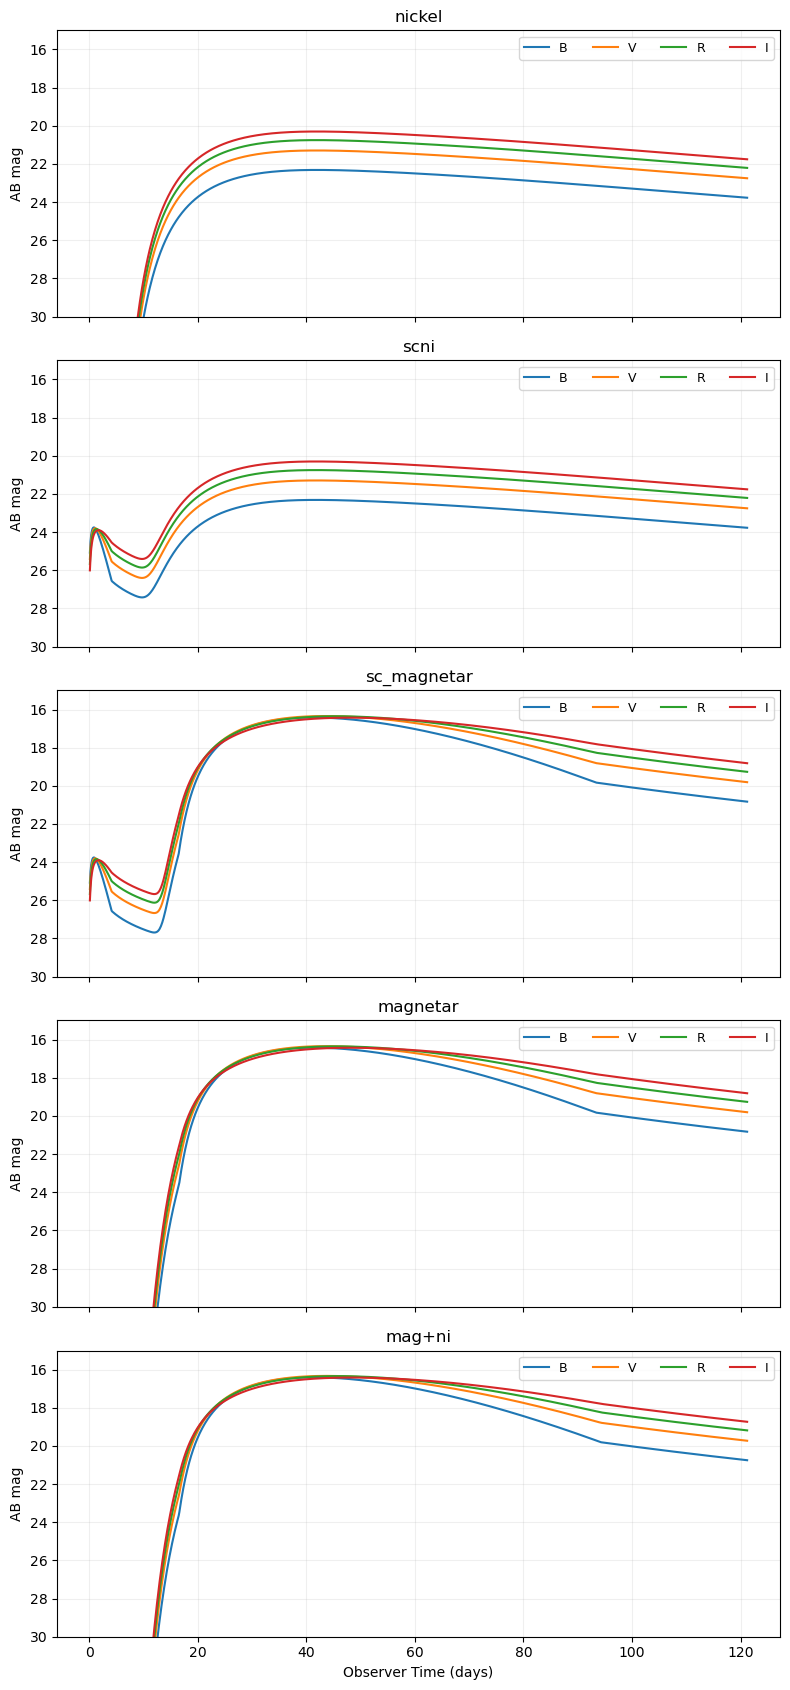

In [3]:
n = len(model_cases)
fig, axes = plt.subplots(n, 1, figsize=(8, 3.4 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, model in zip(axes, model_cases.keys()):
    if model in results:
        lc = results[model]
        for b in bands:
            ax.plot(lc.t_days, lc.y[b], label=b)
        ax.invert_yaxis()
        ax.set_ylabel("AB mag")
        ax.set_ylim(30,15)
        ax.set_title(model)
        ax.grid(alpha=0.2)
        ax.legend(ncol=4, fontsize=9)
    else:
        ax.text(0.5, 0.5, f"{model} failed", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(model)

axes[-1].set_xlabel("Observer Time (days)")

plt.tight_layout()
plt.show()

In [4]:
assert len(failed) == 0, f"These models failed: {failed}"
print("All five models ran successfully.")

All five models ran successfully.
